# Assignment 1: Understanding and Training a Neural Network

## Part 1: Key Concepts

| Term | Simple meaning | Example |
|------|---------------|---------|
| **Neuron** | The basic unit of a neural network. It takes inputs, multiplies each by a weight, adds a bias, and passes the result through an activation function. Output = activation(w·x + b) | A neuron predicting a house price from its size |
| **Weight** | A number that says how important an input is. The network learns the weights during training. | A bigger weight on "size" means size affects the price more |
| **Bias** | An extra number added to the sum. It shifts the output up or down so the neuron can fit data that doesn't pass through zero. | A base price even for a very small house |
| **Epoch** | One full pass through the entire training dataset. | 100 epochs means the model sees all the data 100 times |
| **Batch** | A small group of samples processed together before the weights are updated. | 1000 samples with batch size 100 = 10 batches per epoch |
| **Learning rate** | How big a step the model takes when updating weights. Too high is unstable, too low is very slow. | 0.1 = big steps, 0.001 = small careful steps |

**How they work together:** In each epoch, the data is split into batches. For each batch the model makes predictions, the loss measures the error, and the weights and biases are updated by a step controlled by the learning rate. Repeating this over many epochs makes the error smaller.

In [1]:
import torch
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.1


## Part 2: Tensor Operations

A **tensor** is a multi-dimensional array of numbers, the basic data structure in PyTorch. Below I perform four operations: **creation**, **reshaping**, **multiplication** and **indexing**.

In [2]:
# 1. Tensor creation
a = torch.tensor([1, 2, 3, 4, 5, 6])   # from a list
zeros = torch.zeros(2, 3)              # all zeros
ones = torch.ones(2, 3)                # all ones
rand = torch.rand(2, 3)                # random values between 0 and 1
rng = torch.arange(0, 10, 2)           # 0, 2, 4, 6, 8

print("a:", a)
print("zeros:\n", zeros)
print("ones:\n", ones)
print("rand:\n", rand)
print("arange:", rng)
print("shape of a:", a.shape, "| dtype:", a.dtype)

a: tensor([1, 2, 3, 4, 5, 6])
zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
rand:
 tensor([[0.0692, 0.9669, 0.0045],
        [0.9964, 0.4625, 0.7024]])
arange: tensor([0, 2, 4, 6, 8])
shape of a: torch.Size([6]) | dtype: torch.int64


In [3]:
# 2. Reshaping (6 elements can become 2x3 or 3x2)
b = a.reshape(2, 3)
c = a.reshape(3, 2)
d = a.reshape(-1, 2)      # -1 means "work out this size for me"

print("2x3:\n", b)
print("3x2:\n", c)
print("shape using -1:", d.shape)
print("flattened back:", b.flatten())

2x3:
 tensor([[1, 2, 3],
        [4, 5, 6]])
3x2:
 tensor([[1, 2],
        [3, 4],
        [5, 6]])
shape using -1: torch.Size([3, 2])
flattened back: tensor([1, 2, 3, 4, 5, 6])


In [4]:
# 3. Multiplication
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

print("Element-wise x * y:\n", x * y)
print("Matrix multiplication x @ y:\n", x @ y)
print("Multiply by a number (x * 10):\n", x * 10)

# (2x3) @ (3x2) gives (2x2)
m1 = torch.arange(1, 7).reshape(2, 3)
m2 = torch.arange(1, 7).reshape(3, 2)
print("m1 @ m2:\n", m1 @ m2)

Element-wise x * y:
 tensor([[ 5, 12],
        [21, 32]])
Matrix multiplication x @ y:
 tensor([[19, 22],
        [43, 50]])
Multiply by a number (x * 10):
 tensor([[10, 20],
        [30, 40]])
m1 @ m2:
 tensor([[22, 28],
        [49, 64]])


In [5]:
# 4. Indexing and slicing
t = torch.arange(1, 13).reshape(3, 4)
print("t:\n", t)

print("first row:", t[0])
print("row 1, column 2:", t[1, 2])
print("second column:", t[:, 1])
print("first 2 rows, last 2 columns:\n", t[:2, 2:])
print("values greater than 6:", t[t > 6])

t:
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
first row: tensor([1, 2, 3, 4])
row 1, column 2: tensor(7)
second column: tensor([ 2,  6, 10])
first 2 rows, last 2 columns:
 tensor([[3, 4],
        [7, 8]])
values greater than 6: tensor([ 7,  8,  9, 10, 11, 12])


## Part 3: Training a Simple Model on Synthetic Regression Data

I generate data from the rule **y = 3x + 2 + noise**, so the model should learn a **weight close to 3** and a **bias close to 2**. The data is split into training (70%), validation (15%) and test (15%) sets.

In [6]:
torch.manual_seed(42)

N = 1000
X = torch.rand(N, 1) * 10 - 5        # random values between -5 and 5
noise = torch.randn(N, 1) * 1.0      # random noise
y = 3 * X + 2 + noise                # y = 3x + 2 + noise

print("X shape:", X.shape)
print("y shape:", y.shape)
print("first 3 X:", X[:3].flatten())
print("first 3 y:", y[:3].flatten())

X shape: torch.Size([1000, 1])
y shape: torch.Size([1000, 1])
first 3 X: tensor([ 3.8227,  4.1500, -1.1714])
first 3 y: tensor([13.0544, 13.9216, -2.0223])


In [7]:
idx = torch.randperm(N)              # shuffle the positions 0..999

n_train = int(0.70 * N)              # 700
n_val = int(0.15 * N)                # 150

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Train:", X_train.shape[0])
print("Validation:", X_val.shape[0])
print("Test:", X_test.shape[0])

Train: 700
Validation: 150
Test: 150


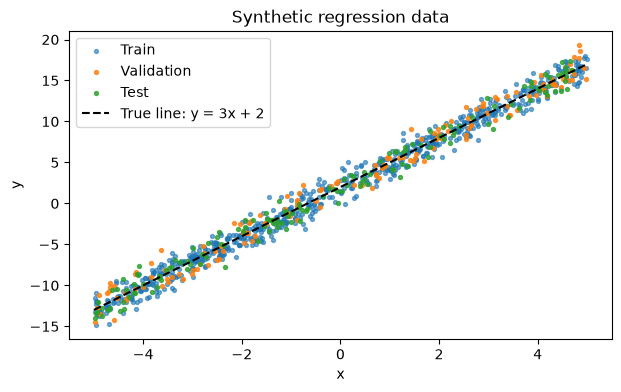

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, s=8, alpha=0.6, label="Train")
plt.scatter(X_val, y_val, s=8, alpha=0.8, label="Validation")
plt.scatter(X_test, y_test, s=8, alpha=0.8, label="Test")

xs = torch.linspace(-5, 5, 100)
plt.plot(xs, 3 * xs + 2, "k--", label="True line: y = 3x + 2")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic regression data")
plt.legend()
plt.show()

### Model, loss and training loop

- **Model:** a single neuron `y = w·x + b` (`nn.Linear(1, 1)`)
- **Loss:** Mean Squared Error (MSE)
- **Optimizer:** SGD (gradient descent), learning rate 0.01, batch size 32
- **Each epoch:** train on all batches, then measure the loss on the validation set (no weight updates)

In [9]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)


def train_model(lr, epochs=50):
    torch.manual_seed(0)                     # same starting weights every run
    model = nn.Linear(1, 1)                  # one neuron: y = w*x + b
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ---- training ----
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            pred = model(xb)                 # 1. forward pass
            loss = loss_fn(pred, yb)         # 2. measure the error
            optimizer.zero_grad()            # 3. clear old gradients
            loss.backward()                  # 4. backpropagation
            optimizer.step()                 # 5. update weights and bias
            running += loss.item() * xb.size(0)
        train_losses.append(running / len(X_train))

        # ---- validation (no learning here) ----
        model.eval()
        with torch.no_grad():
            val_losses.append(loss_fn(model(X_val), y_val).item())

    return model, train_losses, val_losses

In [10]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)


def train_model(lr, epochs=50):
    torch.manual_seed(0)                     # same starting weights every run
    model = nn.Linear(1, 1)                  # one neuron: y = w*x + b
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ---- training ----
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            pred = model(xb)                 # 1. forward pass
            loss = loss_fn(pred, yb)         # 2. measure the error
            optimizer.zero_grad()            # 3. clear old gradients
            loss.backward()                  # 4. backpropagation
            optimizer.step()                 # 5. update weights and bias
            running += loss.item() * xb.size(0)
        train_losses.append(running / len(X_train))

        # ---- validation (no learning here) ----
        model.eval()
        with torch.no_grad():
            val_losses.append(loss_fn(model(X_val), y_val).item())

    return model, train_losses, val_losses

In [11]:
model, train_losses, val_losses = train_model(lr=0.01)

for e in [0, 9, 19, 29, 39, 49]:
    print(f"Epoch {e+1:2d} | train loss {train_losses[e]:.3f} | val loss {val_losses[e]:.3f}")

w = model.weight.item()
b = model.bias.item()
print(f"\nLearned: weight = {w:.3f} (true value 3), bias = {b:.3f} (true value 2)")

model.eval()
with torch.no_grad():
    test_loss = nn.MSELoss()(model(X_test), y_test).item()
print(f"Test loss: {test_loss:.3f}")

Epoch  1 | train loss 13.335 | val loss 2.744
Epoch 10 | train loss 0.985 | val loss 1.400
Epoch 20 | train loss 0.979 | val loss 1.391
Epoch 30 | train loss 0.982 | val loss 1.400
Epoch 40 | train loss 0.985 | val loss 1.398
Epoch 50 | train loss 0.983 | val loss 1.391

Learned: weight = 3.002 (true value 3), bias = 1.937 (true value 2)
Test loss: 1.073


## Part 4: Training and Validation Loss

The curves show how the error changes as the model learns. Both curves drop quickly in the first few epochs and then flatten around **loss ≈ 1**, which matches the noise I added (standard deviation 1). Training and validation losses stay close together, so the model is **not overfitting**.

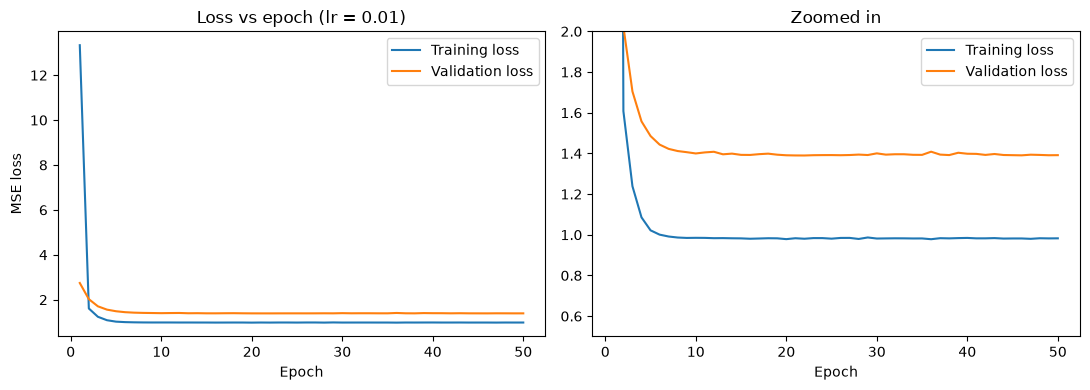

In [12]:
epochs = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Full curve
ax[0].plot(epochs, train_losses, label="Training loss")
ax[0].plot(epochs, val_losses, label="Validation loss")
ax[0].set_title("Loss vs epoch (lr = 0.01)")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE loss")
ax[0].legend()

# Zoomed in on the flat part
ax[1].plot(epochs, train_losses, label="Training loss")
ax[1].plot(epochs, val_losses, label="Validation loss")
ax[1].set_ylim(0.5, 2.0)
ax[1].set_title("Zoomed in")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

## Part 5: Comparing Two Learning Rates

I train the same model on the same data with two learning rates:

- **lr = 0.1:** large steps
- **lr = 0.001:** small steps

Everything else (data, model, starting weights, 50 epochs, batch size 32) is identical, so any difference comes only from the learning rate.

In [13]:
results = {}
for lr in [0.1, 0.001]:
    m, tl, vl = train_model(lr=lr, epochs=50)
    results[lr] = {"model": m, "train": tl, "val": vl}

print("Both models trained.")

Both models trained.


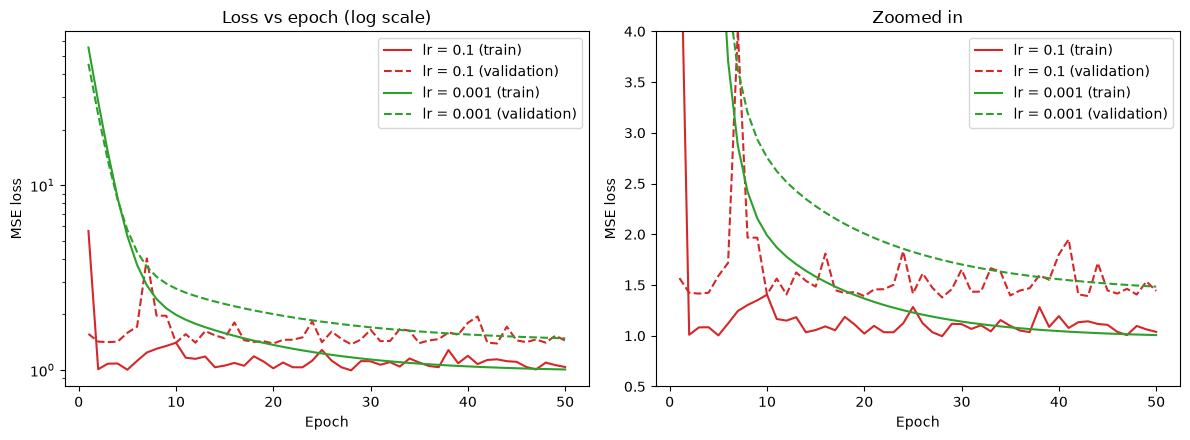

In [14]:
colors = {0.1: "tab:red", 0.001: "tab:green"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

for lr, r in results.items():
    ep = range(1, len(r["train"]) + 1)
    for a in ax:
        a.plot(ep, r["train"], color=colors[lr], label=f"lr = {lr} (train)")
        a.plot(ep, r["val"], color=colors[lr], linestyle="--", label=f"lr = {lr} (validation)")

ax[0].set_yscale("log")
ax[0].set_title("Loss vs epoch (log scale)")
ax[1].set_ylim(0.5, 4)
ax[1].set_title("Zoomed in")

for a in ax:
    a.set_xlabel("Epoch")
    a.set_ylabel("MSE loss")
    a.legend()

plt.tight_layout()
plt.savefig("lr_comparison.png", dpi=150)
plt.show()

In [15]:
def epochs_to_reach(losses, target=2.0):
    for i, loss in enumerate(losses, start=1):
        if loss <= target:
            return str(i)
    return "never"

print(f"{'lr':<8}{'epoch-1 loss':>14}{'epochs to loss<=2':>20}{'final train':>13}{'final val':>11}{'weight':>9}{'bias':>8}")
for lr, r in results.items():
    m = r["model"]
    print(f"{lr:<8}{r['train'][0]:>14.2f}{epochs_to_reach(r['train']):>20}"
          f"{r['train'][-1]:>13.3f}{r['val'][-1]:>11.3f}{m.weight.item():>9.3f}{m.bias.item():>8.3f}")

lr        epoch-1 loss   epochs to loss<=2  final train  final val   weight    bias
0.1               5.65                   2        1.038      1.442    3.074   1.967
0.001            55.66                  10        1.007      1.484    3.003   1.770


### Observations

- **lr = 0.1 (large steps):** the loss falls within the first few epochs, but the curve is noisier and the learned weight wobbles around 3 instead of settling exactly. The big steps slightly overshoot the best values.
- **lr = 0.001 (small steps):** the loss starts much higher and improves slowly. It needs many more epochs to reach the same level, and the bias may still not be fully at 2 after 50 epochs.
- **lr = 0.01 (Part 3):** a middle value that is both fast and stable, so it gave the cleanest result.

**Conclusion:** the learning rate controls the trade-off between speed and stability. Too high gives noisy, unstable training, and too low gives very slow training.

## Summary

| Task | Done |
|------|------|
| 1. Explained neurons, weights, biases, epochs, batches, learning rate | Part 1 |
| 2. Tensor creation, reshaping, multiplication, indexing | Part 2 |
| 3. Trained a model on synthetic regression data (y = 3x + 2 + noise) | Part 3 |
| 4. Plotted training and validation loss | Part 4 |
| 5. Compared two learning rates (0.1 and 0.001) | Part 5 |

The model learned **weight ≈ 3.00** and **bias ≈ 1.94** (true values 3 and 2), with a test loss of about 1.07, close to the noise level of 1.